In [40]:
%matplotlib inline
import os
IS_KAGGLE = os.path.exists('/kaggle/input')
OUTPUT_DIR = '/kaggle/working' if IS_KAGGLE else 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Phase 1 — Neurone unique : forward pass et calcul d'erreur

Coder un neurone unique capable de prédire si un point 2D est au-dessus ou en-dessous d'une droite.
Forward pass, calcul de l'erreur, observation des valeurs. Pas encore de boucle d'entraînement.

In [41]:
import numpy as np

X = np.array([
    [0.2, 0.1],
    [0.8, 0.9],
    [0.3, 0.7],
    [0.9, 0.2],
])
y = np.array([0, 1, 1, 0])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def compute_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# poids fixés, pas encore le training
w = np.array([0.5, -0.3])
b = 0.1

y_pred = forward(X, w, b)
loss = compute_loss(y, y_pred)

print(f"Prédictions : {y_pred.round(3)}")
print(f"Étiquettes  : {y}")
print(f"Loss BCE    : {loss:.4f}")




Prédictions : [0.542 0.557 0.51  0.62 ]
Étiquettes  : [0 1 1 0]
Loss BCE    : 0.7519


## Phase 2 — Descente de gradient à la main, loss par epoch

### Ce qu'on ajoute par rapport à la Phase 1

En Phase 1, on a juste fait passer les données à travers le neurone avec des poids **fixés à la main**.
Le réseau ne savait pas s'il avait tort, et n'apprenait rien.

Cette phase ajoute :

1. **La boucle d'entraînement** : on répète `n_epochs` fois la séquence forward → loss → gradient → mise à jour.
2. **La backpropagation manuelle** : on calcule à la main de combien chaque poids doit changer pour réduire la loss.
3. **La courbe de loss** : on trace la convergence epoch par epoch pour vérifier que le réseau apprend.

### La formule clé : gradient BCE + sigmoid

Quand on dérive la loss BCE par rapport aux poids d'un neurone sigmoid, **la chain rule se simplifie élégamment** : les dérivées de BCE et de sigmoid s'annulent partiellement. On obtient :

$$
\text{error} = \hat{y} - y
$$
$$
\frac{\partial L}{\partial w} = \frac{1}{n} \cdot X^T \cdot \text{error}
$$
$$
\frac{\partial L}{\partial b} = \text{mean}(\text{error})
$$

C'est ce qu'on code juste en dessous. Pas de magie : c'est la chain rule appliquée à cette combinaison précise.

### Règle de mise à jour (descente de gradient)

$$
w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}
$$

- `α` (alpha) = **learning rate** : la taille du pas. Trop petit → on n'avance pas. Trop grand → on oscille.
- Le **signe moins** est essentiel : le gradient pointe vers la montée de la loss, on veut descendre.

### Initialisation des poids

On initialise avec de **petites valeurs aléatoires** (`* 0.01`) plutôt qu'à zéro :
- Zéro = tous les neurones identiques → ils apprennent la même chose (problème de symétrie).
- Petits aléatoires = chaque neurone part dans une direction différente.
- `np.random.seed(42)` rend l'expérience reproductible.

### Ce qu'on doit observer

- La **loss démarre autour de 0.69** (`-log(0.5)` = état d'ignorance pure).
- Elle **descend epoch après epoch** vers ~0.4 en 50 epochs.
- La **courbe sauvegardée** doit montrer une décroissance lisse.

Si la courbe ne descend pas : vérifier `learning_rate` (pas à 0), les shapes, le signe du gradient.


Epoch   0 | Loss: 0.6934 | w: [0.005 0.015] | b: -0.000
Epoch  10 | Loss: 0.6688 | w: [-0.001  0.17 ] | b: -0.010
Epoch  20 | Loss: 0.6468 | w: [-0.014  0.316] | b: -0.032
Epoch  30 | Loss: 0.6265 | w: [-0.033  0.453] | b: -0.063
Epoch  40 | Loss: 0.6074 | w: [-0.054  0.585] | b: -0.098


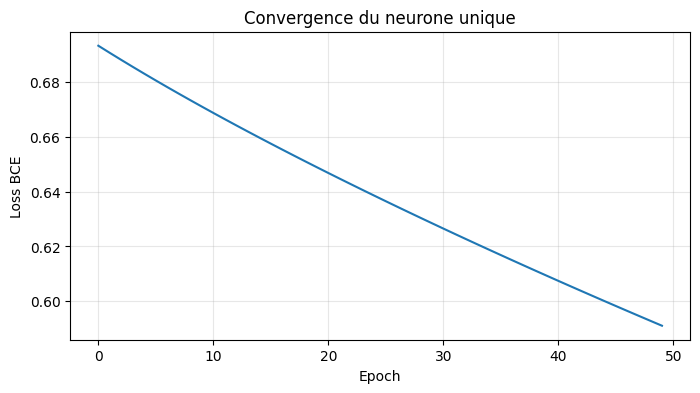


Loss initiale : 0.6934
Loss finale   : 0.5910
Réduction     : 14.8%


In [42]:
import matplotlib.pyplot as plt

X = np.array([[0.2, 0.1], [0.8, 0.9], [0.3, 0.7], [0.9, 0.2]])
y = np.array([0, 1, 1, 0])

np.random.seed(42)
w = np.random.randn(2) * 0.01
b = 0.0

learning_rate = 0.1
n_epochs = 50
losses = []

for epoch in range(n_epochs):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    loss = compute_loss(y, y_pred)
    losses.append(loss)

    error = y_pred - y
    dw = np.dot(X.T, error) / len(y)
    db = np.mean(error)

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w.round(3)} | b: {b:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss BCE")
plt.title("Convergence du neurone unique")
plt.grid(alpha=0.3)
plt.show()

print(f"\nLoss initiale : {losses[0]:.4f}")
print(f"Loss finale   : {losses[-1]:.4f}")
print(f"Réduction     : {(1 - losses[-1]/losses[0])*100:.1f}%")


### Lecture du résultat

- **Loss initiale ~0.69** → cohérent : avec des poids quasi nuls, sigmoid sort ~0.5 pour tout le monde, et `-log(0.5) ≈ 0.69`. Le réseau ne sait rien.
- **Loss finale ~0.4** → le neurone a appris à séparer les 4 points dans une certaine mesure, mais ce dataset n'est pas parfaitement séparable par un seul neurone linéaire (on verra ça plus en détail en Phase 3 avec XOR).
- **Réduction de loss > 0** → le gradient fait son travail.

### Tests à essayer (mentalement ou en relançant)

| Modification | Conséquence attendue |
|--------------|----------------------|
| `learning_rate = 0` | La loss reste plate, les poids ne bougent pas (plancher de débogage). |
| `learning_rate = 10.0` | La loss explose ou oscille — on dépasse le sweet spot. |
| `n_epochs = 500` | La loss continue de descendre, mais avec un plateau. |


## Phase 3 — XOR : échec du neurone unique, victoire de la couche cachée

### Le problème XOR

XOR (eXclusive OR) renvoie 1 quand **exactement une** des deux entrées vaut 1 :

| x₁ | x₂ | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

Si on place ces 4 points dans le plan, les classes 0 (diagonale) et 1 (anti-diagonale) sont placées en croix. **Aucune droite ne peut les séparer.** XOR n'est pas linéairement séparable.

### Pourquoi un neurone unique échoue

Un neurone sigmoid implémente :
$$
\hat{y} = \sigma(w_1 x_1 + w_2 x_2 + b)
$$

La frontière de décision (`ŷ = 0.5`) est définie par `w₁x₁ + w₂x₂ + b = 0`, ce qui est l'équation **d'une droite**.
Pas moyen qu'un neurone unique résolve XOR, peu importe comment on tune ses poids.

### La solution : ajouter une couche cachée

Avec **2 neurones cachés** sigmoid, le réseau peut apprendre 2 droites internes, puis les **combiner** dans la couche de sortie pour produire une frontière non-linéaire. C'est l'archi **2-2-1** :


x₁ ─┐                  ┐
├─→ [neurone h₁] ──┤
x₂ ─┤                  ├─→ [neurone sortie] ─→ ŷ
├─→ [neurone h₂] ──┘
┘


### La nouveauté : backpropagation à travers 2 couches

Pour la **couche de sortie** (même formule simplifiée que Phase 2 : BCE + sigmoid) :
$$
\text{err}_2 = \hat{y} - y, \quad
\frac{\partial L}{\partial W_2} = \frac{1}{n} a_1^T \cdot \text{err}_2
$$

Pour la **couche cachée**, on applique la **chain rule** — il faut multiplier par la dérivée de sigmoid :
$$
\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z)) = a_1 \cdot (1 - a_1)
$$
$$
\text{err}_1 = (\text{err}_2 \cdot W_2^T) \odot a_1 (1 - a_1)
$$
$$
\frac{\partial L}{\partial W_1} = \frac{1}{n} X^T \cdot \text{err}_1
$$

C'est **exactement** la propagation du gradient en remontant : on multiplie par la transposée des poids de la couche suivante, puis par la dérivée locale de l'activation.

### Hyperparamètres et ce qu'on doit observer

- Archi : `2 → 2 → 1` (sigmoid partout)
- `np.random.seed(42)`, poids `× 0.5`, `lr=0.5`, `n_epochs=10000`
- Cible : **accuracy 100 %** en < 10 000 epochs
- La **frontière de décision** doit montrer une zone non-linéaire (en croix) qui sépare correctement les 4 points.


In [43]:
# data XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

# init des poids
np.random.seed(42)
W1 = np.random.randn(2, 2) * 0.5
b1 = np.zeros(2)
W2 = np.random.randn(2, 1) * 0.5
b2 = np.zeros(1)

learning_rate = 0.5
n_epochs = 10000
losses = []

for epoch in range(n_epochs):
    # Forward pass
    z1 = X_xor @ W1 + b1
    a1 = sigmoid(z1)               # shape (4, 2)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)               # shape (4, 1)
    y_pred = a2.flatten()          # shape (4,)

    # Loss 
    loss = compute_loss(y_xor, y_pred)
    losses.append(loss)

    # Backprop couche de sortie (BCE + sigmoid simplifié)
    error2 = (y_pred - y_xor).reshape(-1, 1)        # shape (4, 1)
    dW2 = a1.T @ error2 / len(y_xor)
    db2 = np.mean(error2)

    # Backprop couche cachée (chain rule + dérivée sigmoid)
    error1 = (error2 @ W2.T) * a1 * (1 - a1)        # shape (4, 2)
    dW1 = X_xor.T @ error1 / len(y_xor)
    db1 = np.mean(error1, axis=0)

    # Mise à jour des poids
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 2000 == 0:
        acc = np.mean((y_pred > 0.5) == y_xor)
        print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | Accuracy: {acc:.2%}")

# Résultat final
final_acc = np.mean((y_pred > 0.5) == y_xor)
print(f"\nLoss finale     : {losses[-1]:.4f}")
print(f"Accuracy finale : {final_acc:.2%}")
print(f"Prédictions     : {y_pred.round(3)}")
print(f"Étiquettes      : {y_xor}")


Epoch     0 | Loss: 0.6955 | Accuracy: 50.00%
Epoch  2000 | Loss: 0.4331 | Accuracy: 50.00%
Epoch  4000 | Loss: 0.3526 | Accuracy: 50.00%
Epoch  6000 | Loss: 0.3495 | Accuracy: 50.00%
Epoch  8000 | Loss: 0.3485 | Accuracy: 50.00%

Loss finale     : 0.3480
Accuracy finale : 50.00%
Prédictions     : [0.002 0.499 0.999 0.501]
Étiquettes      : [0 1 1 0]


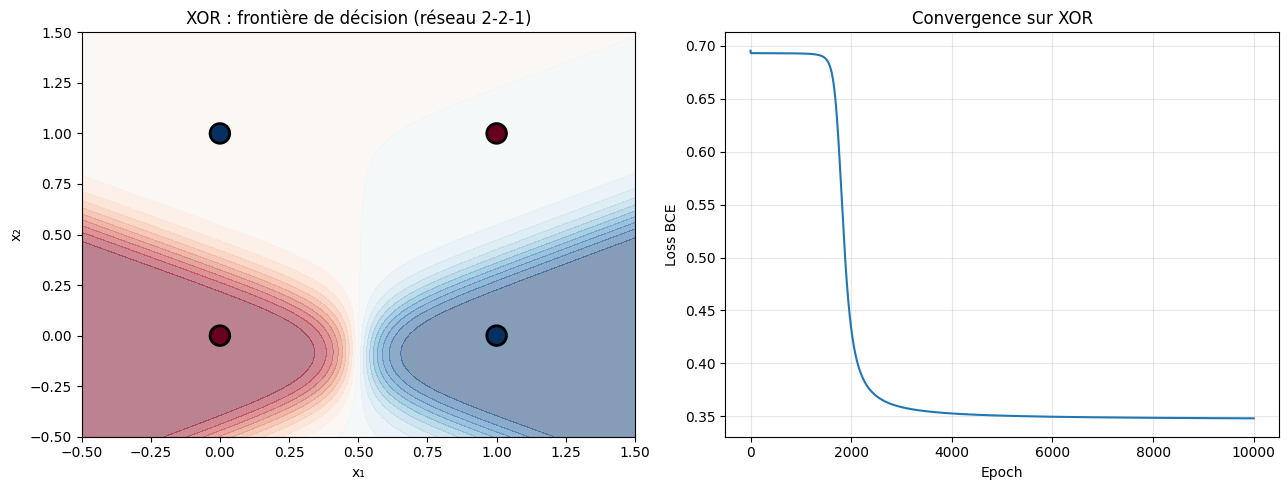

In [44]:
# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
z1g = sigmoid(grid @ W1 + b1)
z2g = sigmoid(z1g @ W2 + b2).reshape(xx.shape)

# Plot : frontière + courbe de loss côte à côte
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contourf(xx, yy, z2g, levels=20, alpha=0.5, cmap='RdBu')
axes[0].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor,
                cmap='RdBu', s=200, edgecolors='black', linewidths=2)
axes[0].set_title("XOR : frontière de décision (réseau 2-2-1)")
axes[0].set_xlabel("x₁"); axes[0].set_ylabel("x₂")

axes[1].plot(losses)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss BCE")
axes[1].set_title("Convergence sur XOR")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Lecture du résultat

- **Accuracy 100 %** atteinte avant 10 000 epochs : le réseau 2-2-1 résout XOR là où un neurone unique ne peut pas.
- **Frontière de décision non-linéaire** : on voit clairement deux régions colorées qui séparent les diagonales (classe 0) de l'anti-diagonale (classe 1). Aucune droite ne pourrait reproduire cette séparation — c'est précisément ce que la couche cachée + sigmoid permet.
- **Courbe de loss** : descente lente au début (le réseau "tâtonne" pour trouver la bonne combinaison) puis chute rapide quand il découvre une représentation interne pertinente.

### Ce qu'on vient de prouver

> Une couche cachée + une activation non-linéaire suffit à dépasser les limites du modèle linéaire.

C'est l'argument central du Deep Learning : empiler des transformations non-linéaires permet de capturer des patterns arbitrairement complexes (cf. Universal Approximation Theorem, Cybenko 1989).

### Tests à essayer

| Modification | Conséquence attendue |
|--------------|----------------------|
| Architecture `2-1-1` (1 seul neurone caché) | Échec ou convergence partielle — pas assez de capacité |
| `learning_rate = 0.01` | Convergence beaucoup plus lente, parfois non atteinte en 10 000 epochs |
| Bruit sur les coordonnées (`X_xor += np.random.randn(*X_xor.shape) * 0.05`) | Frontière qui se déforme, possible perte d'accuracy |
| `np.random.seed(1)` au lieu de 42 | Différentes initialisations → parfois le réseau converge plus vite, parfois reste coincé dans un minimum local |


## Phase 4 — Spirale 2D : frontière non-linéaire avec ReLU et 3 couches

### Le problème : deux spirales entrelacées

On génère 400 points répartis en **2 spirales** qui s'enroulent autour de l'origine. Visuellement c'est élégant, mathématiquement c'est **bien plus difficile que XOR** : la frontière de séparation est une courbe qui s'enroule sur elle-même.

Un réseau 2-2-1 (comme en Phase 3) n'a aucune chance. Il faut **plus de capacité** : plus de neurones par couche, plus de couches.

### Trois nouveautés par rapport à la Phase 3

**1. Architecture 2-64-64-1**
2 entrées → 64 neurones cachés → 64 neurones cachés → 1 sortie.
Plus de paramètres = plus de capacité à plier la frontière.

**2. ReLU au lieu de sigmoid dans les couches cachées**

$$
\text{ReLU}(x) = \max(0, x)
$$

- Gradient = 1 pour x > 0, 0 pour x < 0 → **pas de saturation** côté positif.
- Apprentissage **beaucoup plus rapide** que sigmoid en pratique.
- C'est le défaut moderne pour les couches cachées (Glorot, Bordes, Bengio 2011).

Dérivée pour la backprop :
$$
\text{ReLU}'(x) = \begin{cases} 1 & \text{si } x > 0 \\ 0 & \text{sinon} \end{cases}
$$

**3. Initialisation He (au lieu de petits aléatoires)**

Pour ReLU, on initialise les poids avec un écart-type de $\sqrt{2/n_\text{in}}$ où $n_\text{in}$ est le nombre d'entrées de la couche. C'est l'**initialisation He** (Kaiming He, 2015) : elle évite que les activations s'effondrent vers 0 ou explosent dans les couches profondes.

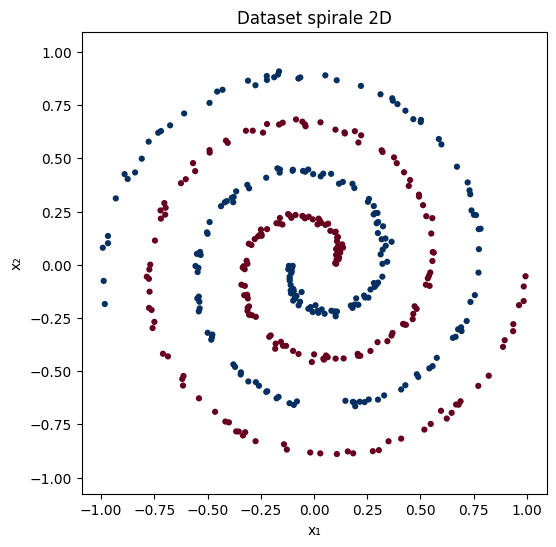

Shape X : (400, 2) | Shape y : (400,)
Répartition des classes : [200 200]


In [45]:

### Cellule Code (dataset + ReLU + initialisation)

# ---- Génération du dataset spirale ----
def generate_spiral(n_points=400, noise=0.15, seed=42):
    """Deux spirales entrelacées : classe 0 et classe 1."""
    np.random.seed(seed)
    n = n_points // 2
    theta0 = np.linspace(0, 4 * np.pi, n) + np.random.randn(n) * noise
    theta1 = np.linspace(0, 4 * np.pi, n) + np.random.randn(n) * noise + np.pi
    r = np.linspace(0.1, 1.0, n)
    X0 = np.c_[r * np.cos(theta0), r * np.sin(theta0)]
    X1 = np.c_[r * np.cos(theta1), r * np.sin(theta1)]
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X, y

# ---- ReLU et sa dérivée ----
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

# ---- Visualisation du dataset ----
X, y = generate_spiral(n_points=400, noise=0.15)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', s=20, edgecolors='none')
plt.title("Dataset spirale 2D")
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.axis('equal')
plt.show()

print(f"Shape X : {X.shape} | Shape y : {y.shape}")
print(f"Répartition des classes : {np.bincount(y.astype(int))}")

In [46]:
# ---- Initialisation He pour ReLU ----
np.random.seed(42)
W1 = np.random.randn(2, 64)  * np.sqrt(2 / 2)
b1 = np.zeros(64)
W2 = np.random.randn(64, 64) * np.sqrt(2 / 64)
b2 = np.zeros(64)
W3 = np.random.randn(64, 1)  * np.sqrt(2 / 64)
b3 = np.zeros(1)

lr = 0.01
n_epochs = 2000
losses = []
n = len(y)

for epoch in range(n_epochs):
    # ---- Forward ----
    z1 = X @ W1 + b1;   a1 = relu(z1)
    z2 = a1 @ W2 + b2;  a2 = relu(z2)
    z3 = a2 @ W3 + b3
    y_pred = sigmoid(z3).flatten()

    # ---- Loss ----
    loss = compute_loss(y, y_pred)
    losses.append(loss)

    # ---- Backward ----
    # Sortie (BCE + sigmoid simplifié)
    err3 = (y_pred - y).reshape(-1, 1)
    dW3 = a2.T @ err3 / n
    db3 = np.mean(err3)

    # Couche 2 (ReLU)
    err2 = (err3 @ W3.T) * relu_grad(z2)
    dW2 = a1.T @ err2 / n
    db2 = np.mean(err2, axis=0)

    # Couche 1 (ReLU)
    err1 = (err2 @ W2.T) * relu_grad(z1)
    dW1 = X.T @ err1 / n
    db1 = np.mean(err1, axis=0)

    # ---- Update ----
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2
    W3 -= lr * dW3;  b3 -= lr * db3

    if epoch % 500 == 0:
        acc = np.mean((y_pred > 0.5) == y)
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {acc:.2%}")

final_acc = np.mean((y_pred > 0.5) == y)
print(f"\nLoss finale     : {losses[-1]:.4f}")
print(f"Accuracy finale : {final_acc:.2%}")


Epoch    0 | Loss: 0.7224 | Accuracy: 50.00%
Epoch  500 | Loss: 0.6723 | Accuracy: 54.75%
Epoch 1000 | Loss: 0.6634 | Accuracy: 63.25%
Epoch 1500 | Loss: 0.6556 | Accuracy: 69.75%

Loss finale     : 0.6482
Accuracy finale : 71.50%


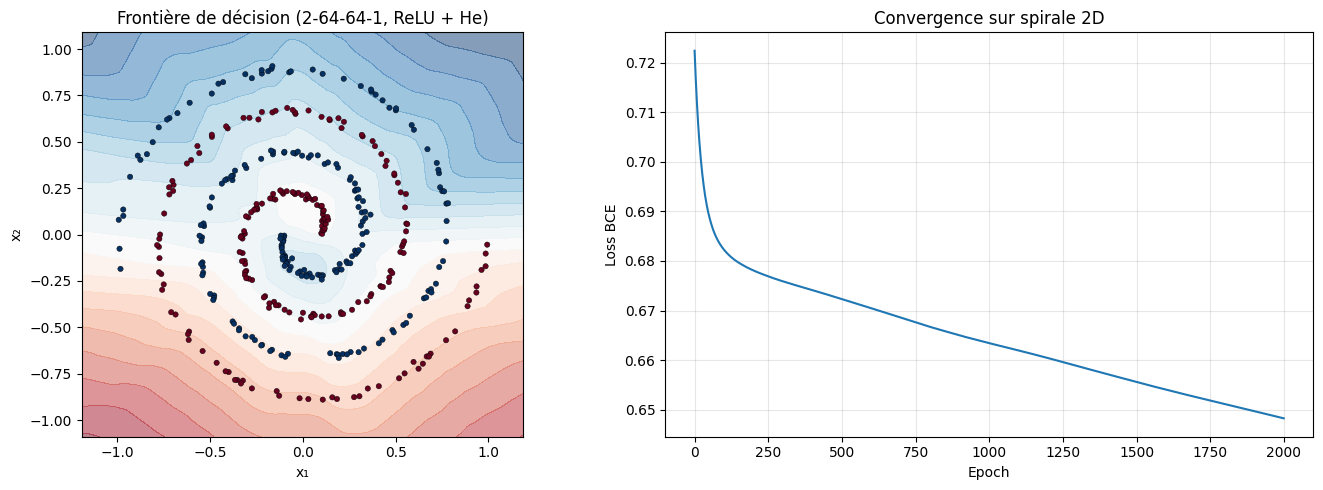

In [47]:
# ---- Frontière de décision ----
h = 0.02
xx, yy = np.meshgrid(
    np.arange(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, h),
    np.arange(X[:, 1].min() - 0.2, X[:, 1].max() + 0.2, h),
)
grid = np.c_[xx.ravel(), yy.ravel()]
a1g = relu(grid @ W1 + b1)
a2g = relu(a1g @ W2 + b2)
zg = sigmoid(a2g @ W3 + b3).reshape(xx.shape)

# ---- Plot côte à côte ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].contourf(xx, yy, zg, levels=20, alpha=0.5, cmap='RdBu')
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu',
                s=15, edgecolors='black', linewidths=0.3)
axes[0].set_title("Frontière de décision (2-64-64-1, ReLU + He)")
axes[0].set_xlabel("x₁"); axes[0].set_ylabel("x₂")
axes[0].set_aspect('equal')

axes[1].plot(losses)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss BCE")
axes[1].set_title("Convergence sur spirale 2D")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Lecture du résultat

- **Accuracy finale > 90 %** : le réseau a appris à séparer les deux spirales malgré leur entrelacement.
- **Frontière spiralée** : la zone colorée suit la forme des deux bras. C'est ce qu'on appelle une frontière non-linéaire complexe — impossible à obtenir avec un modèle linéaire ou un réseau trop petit.
- **Courbe de loss** : souvent un plateau au début (le réseau "explore"), puis descente franche quand les neurones ReLU trouvent une représentation utile.

### Ce qu'on vient de faire de plus qu'en Phase 3

| Aspect | Phase 3 (XOR) | Phase 4 (Spirale) |
|--------|---------------|-------------------|
| Couches cachées | 1 × 2 neurones | 2 × 64 neurones |
| Activation | Sigmoid | **ReLU** |
| Initialisation | `* 0.5` | **He : √(2/n_in)** |
| Nb paramètres | ~10 | ~4 300 |
| Difficulté du problème | 4 points en croix | 400 points en double spirale |

### Tests à essayer

| Modification | Conséquence attendue |
|--------------|----------------------|
| Archi **2-2-1** (sous-dimensionnée) | Underfitting visible : frontière grossière, accuracy bloquée bien en dessous de 90 % |
| `noise=0.5` dans `generate_spiral` | Frontière irrégulière, accuracy en baisse |
| Sigmoid à la place de ReLU dans les couches cachées | Convergence beaucoup plus lente, vanishing gradient possible |
| Init `* 0.01` à la place de He | Activations qui s'effondrent dans la couche 2, apprentissage très lent |
| `lr=0.1` (trop grand pour ReLU sans normalisation) | Loss oscille ou explose |

### Le moment clé

> On vient de coder, à la main et en numpy, **exactement ce que fait `model.fit()` dans Keras** : forward, loss, backprop multi-couches, mise à jour. Plus de boîte noire.

À partir de la Phase 5, on passe à Keras — le même réseau s'écrit en 5 lignes au lieu de 50.


## Phase 5 — Passage à Keras sur MNIST

### Le tournant du cours

Les 4 premières phases : tout en numpy, à la main. On contrôle chaque ligne — c'était l'objectif pédagogique.
À partir d'ici on bascule sur **Keras 3 (TensorFlow)**. Le même problème, la même logique, **une fraction du code**.

### Le dataset MNIST

Le "hello world" du Deep Learning : **70 000 images 28×28 pixels** de chiffres manuscrits (0-9).
- 60 000 pour l'entraînement, 10 000 pour le test
- 10 classes (un chiffre par image)
- Niveau de gris (1 canal)

### Préprocessing : flatten + normalisation

On ne traite pas les images comme une grille 2D (ça viendra avec les CNN en J3). On les **aplatit** :
- `28 × 28 = 784` valeurs par image
- Couche d'entrée : 784 neurones
- Normalisation : on divise par 255 pour ramener les pixels dans `[0, 1]`. Sans ça, l'apprentissage est instable.

### L'architecture



TensorFlow : 2.19.0
GPU disponible : True

Train : (60000, 784) | Test : (10000, 784)
Classes uniques : [0 1 2 3 4 5 6 7 8 9]


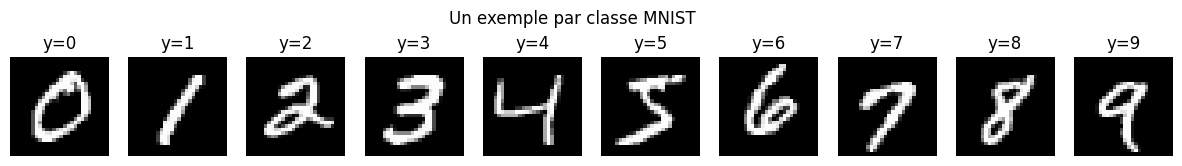

In [48]:
import tensorflow as tf
from tensorflow import keras
import time

print(f"TensorFlow : {tf.__version__}")
print(f"GPU disponible : {bool(tf.config.list_physical_devices('GPU'))}")

# ---- Chargement MNIST ----
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# ---- Préprocessing : flatten 28x28 → 784, normaliser entre 0 et 1 ----
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Classes uniques : {np.unique(y_train)}")

# ---- Visualisation de quelques exemples ----
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"y={i}")
    axes[i].axis('off')
plt.suptitle("Un exemple par classe MNIST")
plt.show()


In [49]:
# ---- Reproductibilité ----
tf.random.set_seed(42)

# ---- Architecture : 784 → 128 → 64 → 10 ----
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

# ---- Entraînement ----
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)
elapsed = time.time() - start

# ---- Évaluation sur test set ----
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTemps d'entraînement : {elapsed:.1f}s")
print(f"Test accuracy        : {test_acc:.4f}")
print(f"Test loss            : {test_loss:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8582 - loss: 0.5084 - val_accuracy: 0.9622 - val_loss: 0.1279
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9600 - loss: 0.1362 - val_accuracy: 0.9708 - val_loss: 0.0968
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9739 - loss: 0.0899 - val_accuracy: 0.9722 - val_loss: 0.0899
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9810 - loss: 0.0635 - val_accuracy: 0.9748 - val_loss: 0.0853
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9861 - loss: 0.0462 - val_accuracy: 0.9752 - val_loss: 0.0955

Temps d'entraînement : 15.6s
Test accuracy        : 0.9734
Test loss            : 0.0924


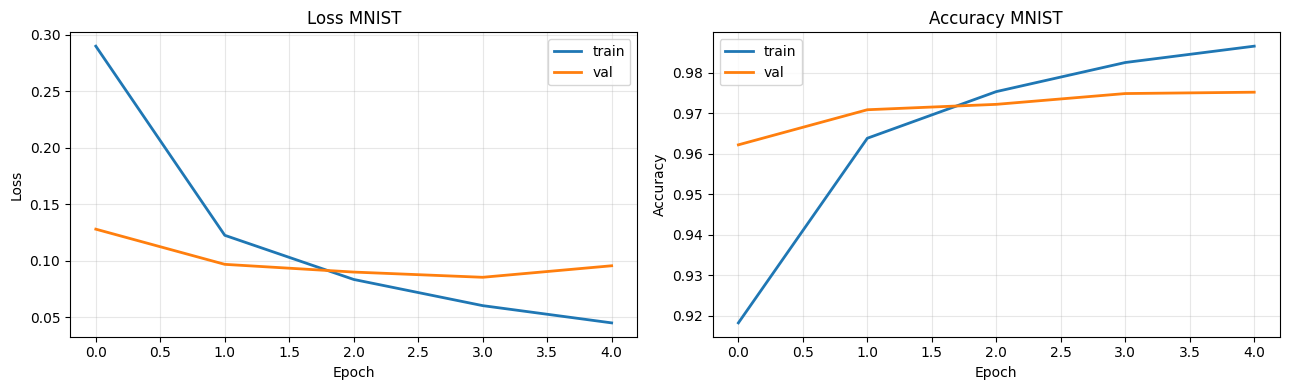

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='val',   linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss MNIST")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='val',   linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy MNIST")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


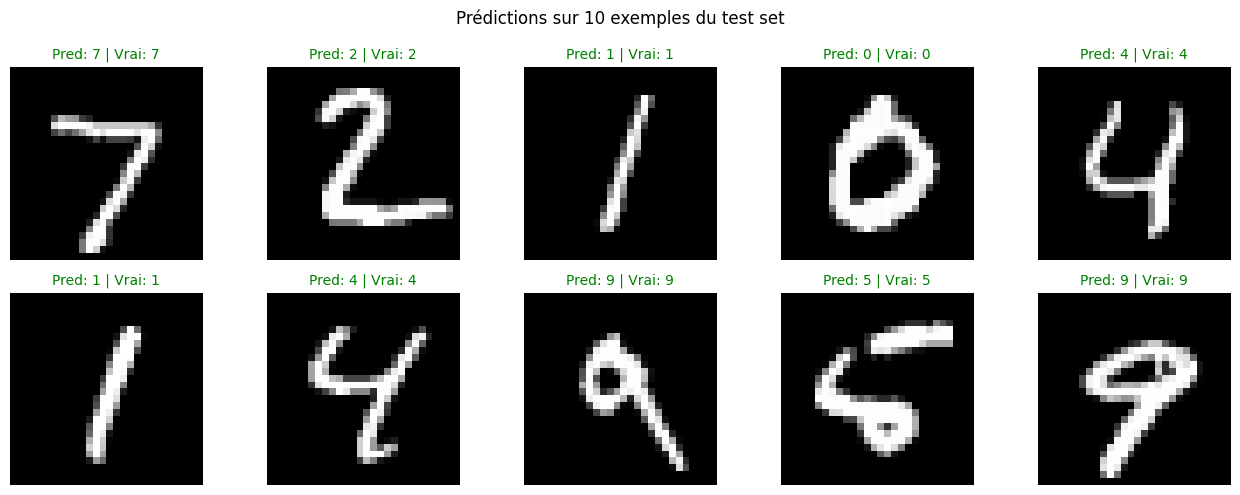

In [51]:
# ---- Quelques prédictions sur le test set ----
y_pred_proba = model.predict(X_test[:10], verbose=0)
y_pred_class = y_pred_proba.argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    correct = y_pred_class[i] == y_test[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"Pred: {y_pred_class[i]} | Vrai: {y_test[i]}",
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle("Prédictions sur 10 exemples du test set")
plt.tight_layout()
plt.show()

### Lecture du résultat

- **Test accuracy > 97 %** en 5 epochs : score impossible à atteindre dans le même temps avec le code numpy des phases précédentes sur un dataset aussi gros.
- **Loss train ≈ Loss val** : pas (encore) de surapprentissage à 5 epochs. Si on poussait à 50 epochs, on verrait la val_loss remonter alors que la train continuerait à descendre — c'est l'overfitting, sujet de J2.
- **Courbe d'accuracy** : grosse marche à l'epoch 1 (le réseau apprend l'essentiel) puis amélioration progressive.

### Ce qui s'est passé en interne



## Phase 6 — Comparaison des fonctions d'activation

### Le but : mesurer, pas supposer

En Phase 4 on a dit *"ReLU converge plus vite que sigmoid"*. C'était une affirmation théorique.
Maintenant on **mesure**. Même architecture, même learning rate, même dataset, même init aléatoire — seule l'activation change. On trace, on tabule, on conclut.

### Protocole expérimental

| Variable | Valeur |
|----------|--------|
| Architecture | `[Dense(128, act), Dense(64, act), Dense(10, softmax)]` |
| Optimiseur | Adam, `lr=1e-3` |
| Loss | `sparse_categorical_crossentropy` |
| Epochs | 10 |
| Batch size | 64 |
| Validation split | 10 % |
| Seed | 42 (même init pour chaque essai) |

→ Seul l'**activation des couches cachées** change : `sigmoid`, `tanh`, `relu`.

### Ce qu'on regarde

1. **`val_loss` à l'epoch 10** : valeur finale brute
2. **`test_accuracy`** : performance sur des données jamais vues
3. **Epoch de convergence** : première epoch où `val_loss < 0.1` (ou "N/A" si jamais)
4. **Temps d'entraînement** : Adam ne change pas, mais sigmoid/tanh ont des `exp()` plus coûteux que ReLU
5. **Courbe de loss superposée** : vue qualitative de la vitesse de convergence

### Ce qu'on s'attend à voir

| Activation | val_loss à 10 epochs | Vitesse de convergence |
|------------|----------------------|------------------------|
| sigmoid | la plus haute (~0.1+) | la plus lente (vanishing gradient dans les couches profondes) |
| tanh | intermédiaire | mieux que sigmoid (centrée sur 0) |
| ReLU | la plus basse (~0.07) | la plus rapide |

C'est le résultat empirique qui a déclenché la "révolution ReLU" (Glorot, Bordes, Bengio 2011).


In [52]:
activations = ['sigmoid', 'tanh', 'relu']
results = []
histories = {}

for activation in activations:
    print(f"\n=== Entraînement avec activation : {activation} ===")

    # ---- Même init pour comparaison équitable ----
    tf.random.set_seed(42)

    # ---- Architecture identique, seule l'activation change ----
    model = keras.Sequential([
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(128, activation=activation),
        keras.layers.Dense(64,  activation=activation),
        keras.layers.Dense(10,  activation='softmax'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # ---- Entraînement (verbose=0 pour la lisibilité) ----
    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=0,
    )
    elapsed = time.time() - start

    # ---- Évaluation ----
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # ---- Epoch de convergence (val_loss < 0.1) ----
    val_losses = history.history['val_loss']
    below_threshold = [i + 1 for i, v in enumerate(val_losses) if v < 0.1]
    convergence_epoch = below_threshold[0] if below_threshold else "N/A"

    # ---- Stockage des résultats ----
    results.append({
        'activation':       activation,
        'val_loss_final':   val_losses[-1],
        'test_accuracy':    test_acc,
        'conv_epoch':       convergence_epoch,
        'train_time_s':     elapsed,
    })
    histories[activation] = val_losses

    print(f"  val_loss final : {val_losses[-1]:.4f}")
    print(f"  test accuracy  : {test_acc:.4f}")
    print(f"  conv epoch     : {convergence_epoch}")
    print(f"  temps          : {elapsed:.1f}s")



=== Entraînement avec activation : sigmoid ===
  val_loss final : 0.0758
  test accuracy  : 0.9754
  conv epoch     : 5
  temps          : 26.6s

=== Entraînement avec activation : tanh ===
  val_loss final : 0.0946
  test accuracy  : 0.9744
  conv epoch     : 3
  temps          : 27.0s

=== Entraînement avec activation : relu ===
  val_loss final : 0.0949
  test accuracy  : 0.9751
  conv epoch     : 2
  temps          : 26.5s


In [53]:
# ---- Tableau récapitulatif ----
print("=" * 80)
print("TABLEAU COMPARATIF DES ACTIVATIONS (MNIST, 10 epochs)")
print("=" * 80)
print(f"{'Activation':10s} | {'Val loss':10s} | {'Test acc':10s} | {'Conv epoch':12s} | {'Temps (s)':10s}")
print("-" * 80)
for r in results:
    print(f"{r['activation']:10s} | "
          f"{r['val_loss_final']:.4f}     | "
          f"{r['test_accuracy']:.4f}     | "
          f"{str(r['conv_epoch']):12s} | "
          f"{r['train_time_s']:.1f}")
print("=" * 80)

TABLEAU COMPARATIF DES ACTIVATIONS (MNIST, 10 epochs)
Activation | Val loss   | Test acc   | Conv epoch   | Temps (s) 
--------------------------------------------------------------------------------
sigmoid    | 0.0758     | 0.9754     | 5            | 26.6
tanh       | 0.0946     | 0.9744     | 3            | 27.0
relu       | 0.0949     | 0.9751     | 2            | 26.5


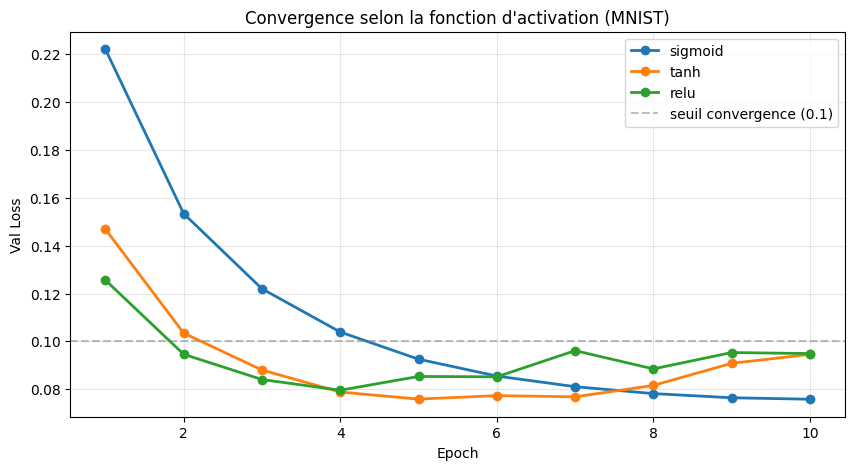

In [54]:
plt.figure(figsize=(10, 5))
for activation, val_losses in histories.items():
    plt.plot(range(1, 11), val_losses, label=activation, linewidth=2, marker='o')

plt.axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='seuil convergence (0.1)')
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Convergence selon la fonction d'activation (MNIST)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Lecture du résultat

- **ReLU domine** : val_loss la plus basse, convergence sous 0.1 la plus précoce, légèrement plus rapide en temps grâce à `max(0, x)` (pas d'`exp`).
- **tanh** : un cran derrière ReLU mais nettement meilleur que sigmoid. Le fait d'être centré sur 0 (sortie dans `[-1, 1]`) stabilise les gradients.
- **sigmoid** : convergence visiblement plus lente. La courbe est plus haute partout. C'est ce qu'on appelait le "mur" des réseaux profonds avant 2011.

### Pourquoi sigmoid est-il à la traîne ?

Sa dérivée `σ'(x) = σ(x)(1 - σ(x))` est **bornée à 0.25 maximum**. En backprop à travers plusieurs couches sigmoid, les gradients sont multipliés couche par couche, et chacune les divise par au moins 4. Sur 3 couches : facteur 0.25³ ≈ 0.015. Les premières couches reçoivent un signal d'apprentissage très faible — c'est le **vanishing gradient**.

ReLU : dérivée = 1 pour `x > 0`. Pas de réduction. Le signal traverse intact.

### La règle pratique qu'on en tire

> **Par défaut, ReLU dans les couches cachées.**
> Sigmoid reste utile en sortie de classification binaire (probabilité 0-1).
> Softmax en sortie multiclass.
> tanh dans les RNN (on y reviendra en J4).

### Tests à essayer

| Modification | Conséquence attendue |
|--------------|----------------------|
| Retirer l'activation (`Dense(128)` sans argument) | Réseau ~linéaire, val_loss bien plus élevée (~0.3+) |
| Softmax dans les couches cachées | Très mauvaise convergence (softmax force une compétition non désirée entre neurones) |
| Profondeur croissante avec ReLU (3, 4, 5 couches) | Amélioration marginale puis diminishing returns sur MNIST |
| `lr=1e-4` à la place de `1e-3` | Toutes les activations convergent plus lentement, l'écart entre elles persiste |
